# Chunk 37 — 25×25 data efficiency

Pre-registered nested-subset comparison of the Chunk 7 GNN and Chunk 36 fixed Gupta CNN. The notebook writes only `ch37_*` artifacts and `checkpoints/ch37_*.pt`; it never loads a non-25×25 graph.

## 1. Install dependencies

Installs the runtime libraries used for graph loading, Parquet, fitting, and metrics. It writes only to the Colab runtime.

In [1]:
!pip -q install torch_geometric pyarrow scipy

## 2. Standard repository and Drive header

Clones or pulls the project, adds `src` to the import path, and mounts Drive with the standard data root. It writes only the repository checkout and Drive mount metadata.

In [2]:
import os,sys,subprocess
REPO_ROOT='/content/antenna_gnn'
if os.path.isdir(f'{REPO_ROOT}/.git'): subprocess.run(['git','-C',REPO_ROOT,'pull','-q'],check=True)
else: subprocess.run(['git','clone','-q','https://github.com/asparagusD/antenna_gnn.git',REPO_ROOT],check=True)
sys.path.insert(0,f'{REPO_ROOT}/src')
from google.colab import drive
drive.mount('/content/drive')
DATA_ROOT='/content/drive/MyDrive/antenna_gnn'
print(REPO_ROOT,DATA_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/antenna_gnn /content/drive/MyDrive/antenna_gnn


## 3. Lock scope, provenance, and output paths

Sets deterministic settings, captures immutable prior artifact/checkpoint mtimes, hashes every input file as it is read, and provides guards for permitted Chunk 37 paths. The pre-registered threshold is fixed at −10 dB; no CNN split manifest is read.

In [3]:
import json,glob,hashlib,zipfile,shutil,time,random,math
from pathlib import Path
import numpy as np,pandas as pd,torch,torch.nn as nn
from torch.utils.data import Dataset,DataLoader,TensorDataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoLoader
from sklearn.metrics import roc_auc_score
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from model import AntennaGNN

GRID,TAU,SEED=25,-10.0,42
ART,CKPT=f'{DATA_ROOT}/artifacts',f'{DATA_ROOT}/checkpoints'
os.makedirs(ART,exist_ok=True);os.makedirs(CKPT,exist_ok=True)
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu');assert DEVICE.type=='cuda','GPU required'
random.seed(SEED);np.random.seed(SEED);torch.manual_seed(SEED);torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic=True;torch.backends.cudnn.benchmark=False;torch.backends.cuda.matmul.allow_tf32=False;torch.backends.cudnn.allow_tf32=False
def sha(p):
 h=hashlib.sha256();
 with open(p,'rb') as f:
  for b in iter(lambda:f.read(1<<20),b''):h.update(b)
 return h.hexdigest()
READ_SHA={}
def READ(p):
 assert os.path.exists(p),f'missing {p}';READ_SHA.setdefault(p,sha(p));return p
def OUT(n): assert n.startswith('ch37_'),n;return f'{ART}/{n}'
def COUT(n): assert n.startswith('ch37_') and n.endswith('.pt'),n;return f'{CKPT}/{n}'
PRIOR=[p for pat in (f'{ART}/ch2[89]_*',f'{ART}/ch3[0-6]_*',f'{CKPT}/*.pt') for p in glob.glob(pat) if os.path.isfile(p) and not Path(p).name.startswith('ch37_')]
MTIME={p:os.path.getmtime(p) for p in PRIOR};GRAPH_LOADS=0;TEST_TOUCHES=0
print('captured immutable mtimes:',len(MTIME))

captured immutable mtimes: 78


## 4. Stage only 25×25 data and create nested, stratified subsets

Stages the 25×25 graph archive to local SSD, reads only `indices.json`, validates the 79,866/9,984/9,983 split sizes, and makes nested subset manifests using the prescribed RNG. It writes `ch37_subsets.json`; labels used for stratification come from raw graph targets, never the CNN split manifest.

*(v2)* The draft alternated the two classes 1:1, which forces about 50% prevalence in every prefix. The ±1-point assertion would fail unless the pool happened to be exactly 50/50. Classes are now merged by their fractional rank, so every prefix keeps the pool's prevalence; I verified this offline on a 58%-prevalence pool. Train-pool lookups use a dictionary instead of `list.index`, which was O(n²).

In [4]:
idx=json.load(open(READ(f'{DATA_ROOT}/splits/indices.json')))
def pairs(v): return {(int(g),int(i)) for g,i in v} if not isinstance(v,dict) else {(int(g),int(i)) for g,x in v.items() for i in x}
S={r:sorted(i for g,i in pairs(idx[r]) if g==GRID) for r in ('train','val','test')}
assert tuple(map(len,(S['train'],S['val'],S['test'])))==(79866,9984,9983)
assert not(set(S['train'])&set(S['val']) or set(S['train'])&set(S['test']) or set(S['val'])&set(S['test']))
POS={i:j for j,i in enumerate(S['train'])}          # local_idx -> position in the train pool (O(1) lookups)
LOCAL='/content/local_graphs/25x25';os.makedirs(LOCAL,exist_ok=True);marker=f'{LOCAL}/_STAGED.txt';z=READ(f'{DATA_ROOT}/data/processed/processed_25x25.zip')
if not os.path.exists(marker):
    with zipfile.ZipFile(z) as Z:
        mem=[m for m in Z.namelist() if m.endswith('.pt')]
        for m in tqdm(mem,desc='stage 25x25'):
            with Z.open(m) as a,open(f'{LOCAL}/{os.path.basename(m)}','wb') as b:shutil.copyfileobj(a,b)
    open(marker,'w').write(str(len(mem)))
def graph(i):
    global GRAPH_LOADS
    assert GRID==25;GRAPH_LOADS+=1;d=torch.load(f'{LOCAL}/sample_{int(i)}.pt',weights_only=False)
    assert d.x[-1,3].item()==-1 and d.y.numel()==201 and d.y.max().item()<=.01;return d
labels=np.array([graph(i).y.min().item()<TAU for i in tqdm(S['train'],desc='pool labels')])
pool_prev=labels.mean();NS=(5000,10000,20000,40000);SUB={}
def stratified_order(rng):
    """Each class is permuted once; items are then merged by their fractional rank within their class
    (k/n_class, with a random tie-break), so EVERY prefix holds each class in its pool proportion.
    v1 alternated the classes 1:1, which forces ~50% prevalence in every prefix and fails the
    prevalence assertion whenever the pool is not 50/50."""
    i0,i1=rng.permutation(np.flatnonzero(~labels)),rng.permutation(np.flatnonzero(labels))
    key=np.r_[(np.arange(len(i0))+rng.random(len(i0)))/len(i0),(np.arange(len(i1))+rng.random(len(i1)))/len(i1)]
    return np.r_[i0,i1][np.argsort(key,kind='stable')]
for seed in (0,1):
    order=stratified_order(np.random.default_rng(370+seed))
    assert len(set(order.tolist()))==len(labels)
    for n in NS:
        prev=labels[order[:n]].mean();assert abs(prev-pool_prev)<=.01,f'prevalence {prev:.4f} vs pool {pool_prev:.4f}'
        SUB[(n,seed)]=[S['train'][j] for j in order[:n]]
    for lo,hi in zip(NS,NS[1:]):assert set(SUB[(lo,seed)])<=set(SUB[(hi,seed)])
json.dump({f'n{n}_s{s}':v for (n,s),v in SUB.items()},open(OUT('ch37_subsets.json'),'w'),indent=1)
print(f'pool prevalence {pool_prev:.4f}',{f'n{n}_s{s}':f'{labels[[POS[i] for i in v]].mean():.4f}' for (n,s),v in SUB.items()})

pool labels:   0%|          | 0/79866 [00:00<?, ?it/s]

pool prevalence 0.5692 {'n5000_s0': '0.5692', 'n10000_s0': '0.5691', 'n20000_s0': '0.5692', 'n40000_s0': '0.5692', 'n5000_s1': '0.5692', 'n10000_s1': '0.5692', 'n20000_s1': '0.5692', 'n40000_s1': '0.5692'}


## 5. Define the frozen model families and local datasets

Defines the exact Chunk 7 GNN and verbatim Chunk 36 flatten CNN, asserts their parameter counts, and provides 25×25-only datasets. Each GNN run recomputes normalization statistics from its own training subset only; validation and test targets remain raw dB for reporting. This cell writes no artifact.

*(v2)* Graphs are cached in RAM the first time a run touches them. The draft re-read every graph from disk on every epoch, which would dominate the wall clock at 300–600 epochs.

In [5]:
class GuptaCNN25(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1=nn.Sequential(nn.Conv2d(1,64,5,padding=2),nn.BatchNorm2d(64),nn.LeakyReLU(.2),nn.Conv2d(64,64,5,padding=2),nn.BatchNorm2d(64),nn.LeakyReLU(.2),nn.Conv2d(64,64,5,padding=2),nn.BatchNorm2d(64),nn.LeakyReLU(.2))
        b2=[nn.Conv2d(64,128,3,padding=1),nn.BatchNorm2d(128),nn.LeakyReLU(.2)]
        for _ in range(4):b2+=[nn.Conv2d(128,128,3,padding=1),nn.BatchNorm2d(128),nn.LeakyReLU(.2)]
        self.block2=nn.Sequential(*b2)
        b3=[nn.Conv2d(128,256,3,padding=1),nn.BatchNorm2d(256),nn.LeakyReLU(.2)]
        for _ in range(7):b3+=[nn.Conv2d(256,256,3,padding=1),nn.BatchNorm2d(256),nn.LeakyReLU(.2)]
        self.block3=nn.Sequential(*b3)
        self.fc=nn.Sequential(nn.Linear(160000,1000),nn.BatchNorm1d(1000),nn.LeakyReLU(.2),nn.Dropout(.4),nn.Linear(1000,500),nn.BatchNorm1d(500),nn.LeakyReLU(.2),nn.Dropout(.4),nn.Linear(500,201))
    def forward(self,x):return self.fc(self.block3(self.block2(self.block1(x))).flatten(1))
def make_gnn():return AntennaGNN(node_feat_dim=5,edge_feat_dim=2,hidden_dim=128,heads=8,edge_dim=16,num_blocks=4,output_dim=201,conv_dropout=.10,mlp_dropout=.10,dropout_from_block=2)
assert sum(p.numel() for p in make_gnn().parameters())==587001
assert sum(p.numel() for p in GuptaCNN25().parameters())==165907473

# In-RAM cache of the graphs a run touches. v1 re-read every graph from disk on every epoch, which at
# 300-600 epochs is most of the wall clock; a 25x25 graph is ~0.1 MB, so 40k train + 10k val ~ 5 GB.
CACHE={}
def cached(i):
    i=int(i)
    if i not in CACHE:
        d=graph(i);CACHE[i]=(d.x,d.edge_index,d.edge_attr,d.y.reshape(1,-1).float())
    return CACHE[i]
class GSet(Dataset):
    def __init__(self,ids,mean=None,std=None):self.ids=ids;self.mean=mean;self.std=std
    def __len__(self):return len(self.ids)
    def __getitem__(self,j):
        x,ei,ea,y=cached(self.ids[j])
        d=Data(x=x,edge_index=ei,edge_attr=ea,y=((y-self.mean)/self.std) if self.mean is not None else y.clone());d.y_raw=y.clone();return d
class CSet(Dataset):
    def __init__(self,ids):self.ids=ids
    def __len__(self):return len(self.ids)
    def __getitem__(self,j):
        x,_,_,y=cached(self.ids[j]);return x[:-1,0].reshape(1,25,25).float(),y.reshape(-1),int(self.ids[j])
def subset_stats(ids):
    ys=torch.stack([cached(i)[3].reshape(-1) for i in tqdm(ids,desc='subset normalization')]);return ys.mean(0),ys.std(0).clamp_min(1e-6)

## 6. Train/resume scheduled runs

Runs the prescribed priority queue (20k, then 5k/10k, then 40k), with per-family recipes, caps, validation-only selection, local per-epoch checkpointing, and Drive best-checkpoint mirroring. It appends `ch37_curves.csv`, appends `ch37_runs.csv`, and creates `checkpoints/ch37_<family>_n<n>_s<seed>.pt`; already completed Drive runs are skipped after hash verification. If the projected remaining queue exceeds the session budget, no new run is scheduled.

*(v2) fixes:*
- **The Drive mirror crashed.** It copied a file onto itself (`SameFileError`). The best model now trains to a local file and is mirrored at the end.
- **The GNN's selection criterion was wrong.** It used raw-dB MSE; the Chunk 7 recipe uses its **normalized** val loss, and that is restored. The CNN keeps raw-dB MSE (Chunk 36). Both families log raw-dB metrics.
- **Resume was broken.** It now restores `bestrow`, elapsed time and the RNG state; the draft would have crashed on `bestrow = None`.
- **No duplicate epoch rows.** A restarted run first removes its old rows from `ch37_curves.csv`.
- **Session budget.** It counts the time already used in this session.
- **Memory.** GPU memory is freed between runs.

In [6]:
CURVES,RUNS=OUT('ch37_curves.csv'),OUT('ch37_runs.csv')
queue=[(20000,s,f) for s in (0,1) for f in ('gnn','cnn')]+[(n,s,f) for n in (5000,10000) for s in (0,1) for f in ('gnn','cnn')]+[(40000,0,f) for f in ('gnn','cnn')]
CAP={'gnn':{5000:600,10000:400,20000:300,40000:200},'cnn':{5000:200,10000:150,20000:100,40000:60}};PATI={'gnn':20,'cnn':10};BATCH={'gnn':128,'cnn':256}
SESSION_HOURS=10;SESSION_T0=time.perf_counter();times=[]
existing=pd.read_csv(RUNS) if os.path.exists(RUNS) else pd.DataFrame()
def append_csv(df,path):df.to_csv(path,mode='a',header=not os.path.exists(path),index=False)
def drop_curve_rows(family,n,seed):
    """A run that restarts from scratch must not leave duplicate epochs from an interrupted attempt."""
    if os.path.exists(CURVES):
        C=pd.read_csv(CURVES);C=C[~((C.family==family)&(C.n==n)&(C.seed==seed))];C.to_csv(CURVES,index=False)
def mirror(local,drive_path):
    """Copy local -> Drive, force the flush, remount, verify by SHA-256 (Chunk 30 lesson).
    v1 passed the SAME path twice, which makes shutil.copy2 raise SameFileError."""
    shutil.copy2(local,drive_path);h=sha(local)
    drive.flush_and_unmount();drive.mount('/content/drive',force_remount=True)
    assert sha(drive_path)==h,'Drive mirror SHA mismatch';return h
def evaluate(model,family,loader,mean=None,std=None):
    """Returns (val MSE dB^2, val MAE dB, val AUROC, normalized val loss [GNN only])."""
    model.eval();ss=sae=sn=0.;P=[];Y=[]
    with torch.no_grad():
        for batch in loader:
            if family=='gnn':
                batch=batch.to(DEVICE);y=batch.y_raw.reshape(-1,201);out=model(batch);p=out*std+mean
                sn+=((out-(y-mean)/std)**2).sum().item()
            else:
                x,y,_=batch;x,y=x.to(DEVICE),y.to(DEVICE);p=model(x)
            ss+=((p-y)**2).sum().item();sae+=(p-y).abs().sum().item();P.append(p.cpu());Y.append(y.cpu())
    p,y=torch.cat(P),torch.cat(Y);lab=(y.min(1).values<TAU).numpy();auc=roc_auc_score(lab,(-p.min(1).values).numpy())
    return ss/y.numel(),sae/y.numel(),auc,(sn/y.numel() if family=='gnn' else None)
def run(n,seed,family):
    global existing
    name=f'ch37_{family}_n{n}_s{seed}.pt';out=COUT(name)
    if len(existing) and ((existing.family==family)&(existing.n==n)&(existing.seed==seed)).any() and os.path.exists(out):
        print('skip',name);return None
    torch.manual_seed(1000+seed);torch.cuda.manual_seed_all(1000+seed);ids=SUB[(n,seed)];mean=std=None
    if family=='gnn':
        mean,std=subset_stats(ids);mean,std=mean.to(DEVICE),std.to(DEVICE)
        tr=GeoLoader(GSet(ids,mean.cpu(),std.cpu()),batch_size=128,shuffle=True,num_workers=0)
        va=GeoLoader(GSet(S['val']),batch_size=256,shuffle=False,num_workers=0)
        m=make_gnn().to(DEVICE);opt=torch.optim.Adam(m.parameters(),lr=1e-3,weight_decay=1e-4)
    else:
        tr=DataLoader(CSet(ids),batch_size=256,shuffle=True,num_workers=0);va=DataLoader(CSet(S['val']),batch_size=256,shuffle=False,num_workers=0)
        m=GuptaCNN25().to(DEVICE);opt=torch.optim.NAdam(m.parameters(),lr=1e-3,weight_decay=0)
    sch=torch.optim.lr_scheduler.ReduceLROnPlateau(opt,mode='min',factor=.5,patience=5,min_lr=1e-6)
    local=f'/content/{name}.running';best_local=f'/content/{name}.best'
    start,best,bad,steps,bestrow,elapsed=1,float('inf'),0,0,None,0.
    if os.path.exists(local):   # resume within the same runtime (local SSD survives only within a session)
        c=torch.load(local,map_location=DEVICE,weights_only=False);m.load_state_dict(c['model']);opt.load_state_dict(c['opt']);sch.load_state_dict(c['sch'])
        start,best,bad,steps,bestrow,elapsed=c['epoch']+1,c['best'],c['bad'],c['steps'],c['bestrow'],c['elapsed']
        torch.set_rng_state(c['rng'].cpu());torch.cuda.set_rng_state_all([t.cpu() for t in c['cuda_rng']]);print('resumed',name,'at epoch',start)
    else:
        drop_curve_rows(family,n,seed)
    t0=time.perf_counter()-elapsed;ep=start-1
    for ep in range(start,CAP[family][n]+1):
        m.train();tot=0
        for batch in tqdm(tr, desc=f'{family} ep {ep}/{CAP[family][n]}', leave=False):
            if family=='gnn':batch=batch.to(DEVICE);x,y=batch,batch.y.reshape(-1,201)
            else:x,y,_=batch;x,y=x.to(DEVICE),y.to(DEVICE)
            opt.zero_grad(set_to_none=True);loss=nn.functional.mse_loss(m(x),y);loss.backward();torch.nn.utils.clip_grad_norm_(m.parameters(),1.);opt.step();tot+=loss.item()*len(y);steps+=1
        vmse,vmae,vauc,vnorm=evaluate(m,family,va,mean,std)
        # Selection criterion = each family's own training loss on val: normalized MSE for the GNN
        # (Chunk 7 recipe), raw-dB MSE for the CNN (Chunk 36 recipe). Raw-dB metrics are logged for both.
        crit=vnorm if family=='gnn' else vmse
        sch.step(crit)
        row=dict(family=family,n=n,seed=seed,epoch=ep,optimizer_steps=steps,samples_seen=steps*BATCH[family],wall_seconds=time.perf_counter()-t0,
                 train_loss=tot/n,val_criterion=crit,val_mse_db2=vmse,val_mae_db=vmae,val_auroc=vauc,lr=opt.param_groups[0]['lr'])
        append_csv(pd.DataFrame([row]),CURVES)
        if crit<best:
            best,bad,bestrow=crit,0,row
            torch.save({'model_state':m.state_dict(),'family':family,'n':n,'seed':seed,'mean':mean.cpu() if mean is not None else None,
                        'std':std.cpu() if std is not None else None,'n_params':sum(p.numel() for p in m.parameters()),'best_epoch':ep},best_local)
        else:bad+=1
        torch.save(dict(model=m.state_dict(),opt=opt.state_dict(),sch=sch.state_dict(),epoch=ep,best=best,bad=bad,steps=steps,bestrow=bestrow,
                        elapsed=time.perf_counter()-t0,rng=torch.get_rng_state(),cuda_rng=torch.cuda.get_rng_state_all()),local)
        if bad>=PATI[family]:break
    h=mirror(best_local,out);total=time.perf_counter()-t0
    budget=bestrow['epoch']>CAP[family][n]-PATI[family]
    r=dict(family=family,n=n,seed=seed,n_params=sum(p.numel() for p in m.parameters()),best_epoch=bestrow['epoch'],epochs_run=ep,
           steps_to_best=bestrow['optimizer_steps'],samples_seen_to_best=bestrow['samples_seen'],seconds_to_best=bestrow['wall_seconds'],total_seconds=total,
           val_mse_db2=bestrow['val_mse_db2'],val_mae_db=bestrow['val_mae_db'],val_auroc=bestrow['val_auroc'],budget_limited=budget,
           subset_prevalence=float(labels[[POS[i] for i in ids]].mean()),checkpoint=out,checkpoint_sha256=h)
    append_csv(pd.DataFrame([r]),RUNS);existing=pd.read_csv(RUNS);times.append(total)
    for f in (local,best_local):
        if os.path.exists(f):os.remove(f)
    del m,opt,tr,va;torch.cuda.empty_cache()
    print({k:r[k] for k in ('family','n','seed','best_epoch','epochs_run','val_mae_db','val_auroc','budget_limited')},f'| {total/60:.1f} min')
    return r
for job in queue:
    used=(time.perf_counter()-SESSION_T0)/3600
    if times and used+np.mean(times)/3600>SESSION_HOURS:
        print(f'session budget: {used:.1f} h used; the next run would exceed {SESSION_HOURS} h - stopping here (re-run this cell in a new session to continue)');break
    run(*job)
print('completed runs:',len(pd.read_csv(RUNS)) if os.path.exists(RUNS) else 0,'of',len(queue))

skip ch37_gnn_n20000_s0.pt
skip ch37_cnn_n20000_s0.pt
skip ch37_gnn_n20000_s1.pt
skip ch37_cnn_n20000_s1.pt
skip ch37_gnn_n5000_s0.pt
skip ch37_cnn_n5000_s0.pt
skip ch37_gnn_n5000_s1.pt
skip ch37_cnn_n5000_s1.pt
skip ch37_gnn_n10000_s0.pt
skip ch37_cnn_n10000_s0.pt
skip ch37_gnn_n10000_s1.pt
skip ch37_cnn_n10000_s1.pt
skip ch37_gnn_n40000_s0.pt
skip ch37_cnn_n40000_s0.pt
completed runs: 14 of 14


## 7. Validation harness before test access

Loads the full-data reference models and validates their 25×25 validation minima against Chunk 35/36 output. This is a read-only guard: `best_model` must match within 1e-3 dB and the Chunk 36 CNN within 2e-2 dB with at least 99.9% agreement of fixed −10 dB decisions. It writes nothing and does not load test graphs.

*(v2)* `ch36_per_sample.parquet` holds only TEST rows. The draft compared VAL predictions with them, which would fail or compare the wrong graphs. The CNN check is now against the validation MSE recorded in its own Chunk 36 checkpoint.

In [7]:
def state(path):
    c=torch.load(READ(path),map_location='cpu',weights_only=False);s=c.get('model_state',c)
    return {k[7:] if k.startswith('module.') else k:v for k,v in s.items()},c
def predict(model,family,ids,mean=None,std=None):
    """Per-sample (true_min, pred_min, mse, mae, true_argmin, pred_argmin) plus the full curves (float32)."""
    loader=GeoLoader(GSet(ids),batch_size=256,shuffle=False,num_workers=0) if family=='gnn' else DataLoader(CSet(ids),batch_size=256,shuffle=False,num_workers=0)
    model.eval();P=[];Y=[]
    with torch.no_grad():
        for b in loader:
            if family=='gnn':b=b.to(DEVICE);y=b.y_raw.reshape(-1,201).cpu();p=(model(b)*std+mean).float().cpu()
            else:x,y,_=b;p=model(x.to(DEVICE)).float().cpu()
            P.append(p);Y.append(y.float())
    P,Y=torch.cat(P).numpy(),torch.cat(Y).numpy()
    rows=np.c_[Y.min(1),P.min(1),((P-Y)**2).mean(1),np.abs(P-Y).mean(1),Y.argmin(1),P.argmin(1)]
    return rows,P,Y
orig_mean=torch.tensor(np.load(READ(f'{ART}/s11_mean.npy')),dtype=torch.float32,device=DEVICE)
orig_std=torch.tensor(np.load(READ(f'{ART}/s11_std.npy')),dtype=torch.float32,device=DEVICE)
sg,_=state(f'{CKPT}/best_model.pt');refg=make_gnn();refg.load_state_dict(sg,strict=True);refg=refg.to(DEVICE).eval()
sc,cc=state(f'{CKPT}/ch36_gupta_cnn25_best.pt');refc=GuptaCNN25();refc.load_state_dict(sc,strict=True);refc=refc.to(DEVICE).eval()
vg,_,_=predict(refg,'gnn',S['val'],orig_mean,orig_std);vc,_,_=predict(refc,'cnn',S['val'])
p35=pd.read_parquet(READ(f'{ART}/ch35_per_sample.parquet'))
a=p35[(p35.role=='VAL')&(p35.grid==25)&(p35.model_id=='best_model')].sort_values('local_idx')
assert a.local_idx.tolist()==S['val']
dg=np.abs(vg[:,1]-a.pred_min_db.to_numpy())
print(f'best_model VAL vs Chunk 35: max |diff| {dg.max():.1e} dB, within 1e-3 dB: {(dg<1e-3).mean():.4%}')
assert (dg<1e-3).mean()>=.999
# Chunk 36 saved only TEST per-sample predictions, so the CNN's VAL check is against the validation MSE
# recorded in its own checkpoint at the selected epoch (v1 compared VAL predictions with TEST rows).
cnn_val_mse=float(vc[:,2].mean());ref_val=float(cc['best_val'])
print(f'gupta_cnn25 VAL MSE {cnn_val_mse:.6f} vs checkpoint best_val {ref_val:.6f} (|diff| {abs(cnn_val_mse-ref_val):.1e})')
assert abs(cnn_val_mse-ref_val)<1e-3,'STOP: Chunk 36 CNN does not reproduce its recorded validation MSE'
HARNESS=True;print('VAL harness passed; TEST remains untouched')

best_model VAL vs Chunk 35: max |diff| 9.3e-05 dB, within 1e-3 dB: 100.0000%
gupta_cnn25 VAL MSE 1.283708 vs checkpoint best_val 1.283708 (|diff| 1.7e-08)
VAL harness passed; TEST remains untouched


## 8. TEST TOUCH — evaluate completed runs once

This is the sole guarded test inference cell. It evaluates every completed Chunk 37 checkpoint plus the two full-data references on the 9,983 test graphs, computes all fixed-threshold metrics and per-sample errors (without full curves), and writes `ch37_test_metrics.csv` and `ch37_per_sample.parquet`. No test result controls training or selection.

*(v2)* Pooled R² is now computed; the draft hardcoded NaN. Balanced accuracy is reported both on balanced subsamples and on the natural mix. The cell also prints a reproduction check of `gnn_full` against Chunk 36 (MAE 0.3742, AUROC 0.9040).

In [8]:
assert globals().get('HARNESS') is True and TEST_TOUCHES==0;TEST_TOUCHES+=1
runs=pd.read_csv(RUNS)
models=[('gnn_full',refg,'gnn',orig_mean,orig_std),('cnn_full',refc,'cnn',None,None)]
for r in tqdm(runs.itertuples(), total=len(runs), desc='Loading checkpoints'):
    s,c=state(r.checkpoint);m=make_gnn() if r.family=='gnn' else GuptaCNN25();m.load_state_dict(s,strict=True)
    mu=torch.as_tensor(c['mean'],device=DEVICE) if c['mean'] is not None else None;sd=torch.as_tensor(c['std'],device=DEVICE) if c['std'] is not None else None
    models.append((f'{r.family}_n{r.n}_s{r.seed}',m,r.family,mu,sd))
F=np.linspace(1,4,201)
def ba(y,h):return .5*(((h[y==1]==1).mean())+((h[y==0]==0).mean()))
def mf(y,h):
    tp=((y==1)&(h==1)).sum();tn=((y==0)&(h==0)).sum();fp=((y==0)&(h==1)).sum();fn=((y==1)&(h==0)).sum()
    return .5*(2*tp/max(2*tp+fp+fn,1)+2*tn/max(2*tn+fn+fp,1))
rows=[];met=[]
for name,m,fam,mu,sd in tqdm(models,desc='TEST'):
    m=m.to(DEVICE).eval();q,P,Y=predict(m,fam,S['test'],mu,sd)
    truth,pred=q[:,0],q[:,1];lab=(truth<TAU).astype(int);hat=(pred<TAU).astype(int)
    rng=np.random.default_rng(36);i0,i1=np.flatnonzero(lab==0),np.flatnonzero(lab==1);k=min(len(i0),len(i1));bs=[]
    for _ in range(1000):
        ii=np.r_[rng.choice(i0,k,replace=False),rng.choice(i1,k,replace=False)];bs.append((ba(lab[ii],hat[ii]),mf(lab[ii],hat[ii])))
    for i,local in enumerate(S['test']):
        rows.append(dict(model_id=name,local_idx=local,true_min_db=truth[i],pred_min_db=pred[i],mse_db2=q[i,2],mae_db=q[i,3],
                         true_argmin_ghz=F[int(q[i,4])],pred_argmin_ghz=F[int(q[i,5])]))
    sse,sst=float(((P-Y)**2).sum()),float(((Y-Y.mean())**2).sum())
    met.append(dict(model_id=name,mse_db2=q[:,2].mean(),rmse_db=np.sqrt(q[:,2].mean()),mae_db=q[:,3].mean(),r2_pooled=1-sse/sst,
                    auroc=roc_auc_score(lab,-pred),balanced_accuracy_balanced_subsample=np.mean(bs,0)[0],macro_f1_balanced_subsample=np.mean(bs,0)[1],
                    balanced_accuracy_natural=ba(lab,hat),resonant_freq_mae_ghz=np.abs(F[q[lab==1,4].astype(int)]-F[q[lab==1,5].astype(int)]).mean()))
    if name not in ('gnn_full','cnn_full'):del m;torch.cuda.empty_cache()
PER=pd.DataFrame(rows);PER.to_parquet(OUT('ch37_per_sample.parquet'),index=False)
MET=pd.DataFrame(met);MET.to_csv(OUT('ch37_test_metrics.csv'),index=False)
print(MET.round(4).to_string(index=False))
g=MET.set_index('model_id').loc['gnn_full']
print(f"check: gnn_full test MAE {g.mae_db:.4f} (Chunk 36: 0.3742), AUROC {g.auroc:.4f} (0.9040)")

Loading checkpoints:   0%|          | 0/14 [00:00<?, ?it/s]

TEST:   0%|          | 0/16 [00:00<?, ?it/s]

     model_id  mse_db2  rmse_db  mae_db  r2_pooled  auroc  balanced_accuracy_balanced_subsample  macro_f1_balanced_subsample  balanced_accuracy_natural  resonant_freq_mae_ghz
     gnn_full   1.3175   1.1478  0.3742     0.8425 0.9040                                0.8259                       0.8219                     0.8259                 0.1214
     cnn_full   1.2932   1.1372  0.3795     0.8454 0.9047                                0.8246                       0.8203                     0.8245                 0.1193
gnn_n20000_s0   1.6570   1.2872  0.4472     0.8019 0.9028                                0.8183                       0.8134                     0.8183                 0.1274
cnn_n20000_s0   1.8141   1.3469  0.4718     0.7831 0.8964                                0.8089                       0.8027                     0.8088                 0.1310
gnn_n20000_s1   1.6669   1.2911  0.4405     0.8007 0.8999                                0.8147                       0.8099 

## 9. Analyze learning, data need, speed, and paired comparisons

Builds learning/speed figures, fits the registered power law on 5k–40k points, calculates interpolation-based data requirements and the 20k verdict, and performs same-seed paired test bootstraps. It writes `ch37_learning_curves.png`, `ch37_speed_n20k.png`, `ch37_paired.csv`, and `ch37_report.md`.

*(v2) fixes:*
- **The AUROC "difference" was wrong.** The draft took the mean difference of predicted minima, which is not AUROC. It is now a genuine paired, stratified-bootstrap AUROC difference.
- **`PAIR.to_csv` crashed,** because `PAIR` was a list.
- **The data-needed rule mishandled two cases:** it now catches targets already met at 5k, and the interpolation is fixed.
- **Power-law fits:** the exponent is bounded to [0, 3], failures are recorded rather than raised, and the fits are labelled descriptive (4 points, 3 parameters).
- **The speed table** now includes samples and minutes to reach within 5% of each run's best.

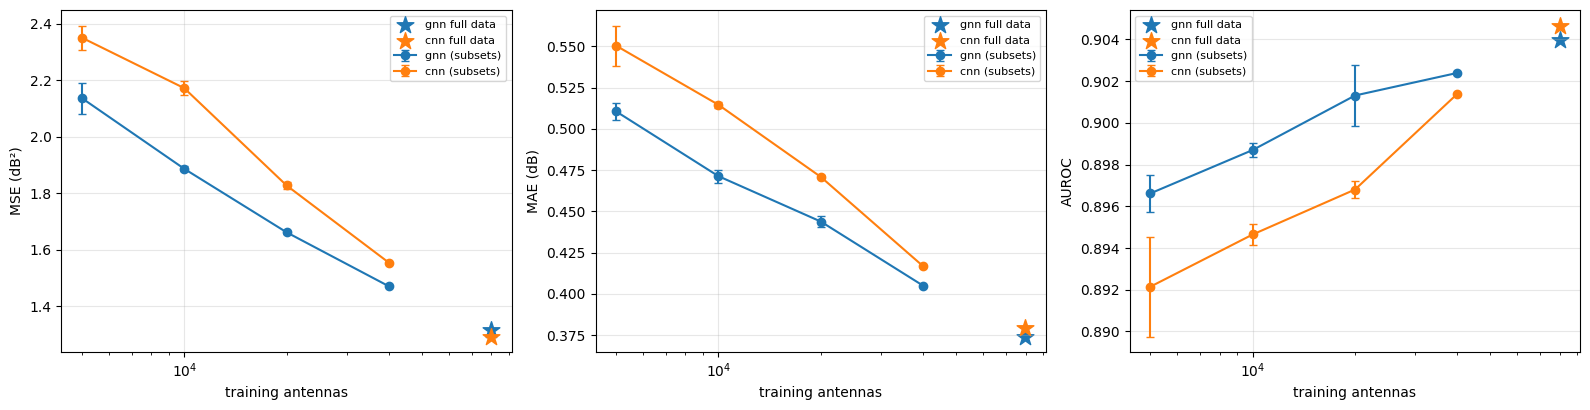

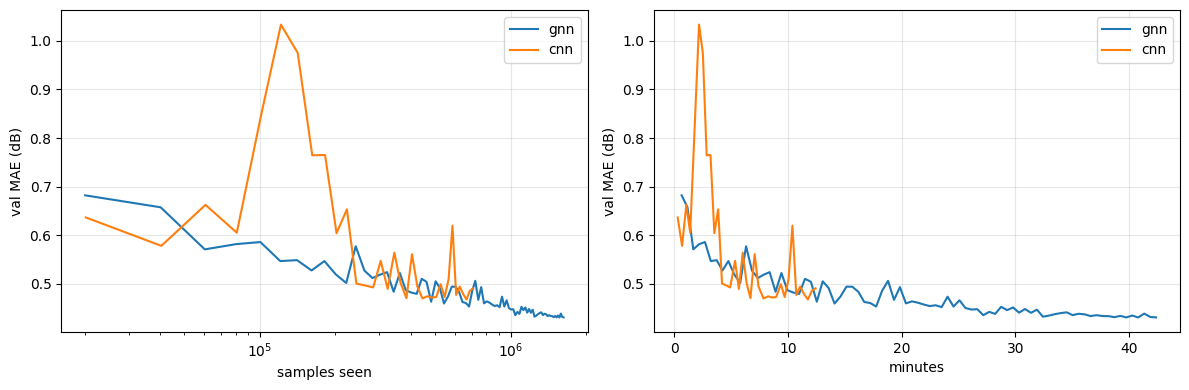

NOTE: 3-parameter fits on 4 points have 1 residual degree of freedom; treat b and c as descriptive.
# Chunk 37 — Data efficiency (25×25)

Both families train on exactly the same nested, prevalence-stratified 25×25 subsets, with validation-only selection.
Full-data reference points: `best_model.pt` (Chunk 7) and `ch36_gupta_cnn25_best.pt` (Chunk 36), evaluated here on the same test set.
GNN normalization statistics are recomputed per subset. Selection uses each family's own training loss on val
(normalized MSE for the GNN, raw-dB MSE for the CNN); raw-dB metrics are reported for both.

## Test metrics
| model_id      |   mse_db2 |   rmse_db |   mae_db |   r2_pooled |   auroc |   balanced_accuracy_balanced_subsample |   macro_f1_balanced_subsample |   balanced_accuracy_natural |   resonant_freq_mae_ghz |
|:--------------|----------:|----------:|---------:|------------:|--------:|---------------------------------------:|------------------------------:|----------------------------:|-------

In [9]:
def nval(mid):return int(mid.split('_n')[1].split('_s')[0])
M=MET.copy();M['family']=M.model_id.str.split('_').str[0];sub=M[M.model_id.str.contains('_n')].copy();sub['n']=sub.model_id.map(nval)
full=M.set_index('model_id')
NAMES={'mse_db2':'MSE (dB²)','mae_db':'MAE (dB)','auroc':'AUROC'}
fig,ax=plt.subplots(1,3,figsize=(16,4.2))
for j,k in enumerate(NAMES):
    for fam,col in (('gnn','C0'),('cnn','C1')):
        g=sub[sub.family==fam].groupby('n')[k].agg(['mean','min','max']).sort_index()
        ax[j].errorbar(g.index,g['mean'],yerr=[g['mean']-g['min'],g['max']-g['mean']],marker='o',color=col,capsize=3,label=f'{fam} (subsets)')
        ax[j].scatter([79866],[full.loc[f'{fam}_full',k]],marker='*',s=160,color=col,label=f'{fam} full data')
    ax[j].set_xscale('log');ax[j].set(xlabel='training antennas',ylabel=NAMES[k]);ax[j].grid(alpha=.3);ax[j].legend(fontsize=8)
fig.tight_layout();fig.savefig(OUT('ch37_learning_curves.png'),dpi=180);plt.show()
C=pd.read_csv(CURVES)
fig,ax=plt.subplots(1,2,figsize=(12,4))
for fam in ('gnn','cnn'):
    d=C[(C.n==20000)&(C.seed==0)&(C.family==fam)].sort_values('epoch')
    ax[0].plot(d.samples_seen,d.val_mae_db,label=fam);ax[1].plot(d.wall_seconds/60,d.val_mae_db,label=fam)
for a in ax:a.legend();a.grid(alpha=.3);a.set_ylabel('val MAE (dB)')
ax[0].set_xlabel('samples seen');ax[1].set_xlabel('minutes');ax[0].set_xscale('log')
fig.tight_layout();fig.savefig(OUT('ch37_speed_n20k.png'),dpi=180);plt.show()

fits=[]
for fam in ('gnn','cnn'):
    for k in NAMES:
        g=sub[sub.family==fam].groupby('n')[k].mean().sort_index();x,y=g.index.values.astype(float),g.values
        rec=dict(family=fam,metric=k,n_points=len(x),measured_full=full.loc[f'{fam}_full',k])
        try:
            if len(x)<4:raise RuntimeError('fewer than 4 subset sizes')
            fun=lambda x,a,b,c:a*x**(-b)+c
            p0=(y[0]-y[-1],0.5,y[-1]) if k!='auroc' else (-(y[-1]-y[0]),0.5,y[-1])
            po,cv=curve_fit(fun,x,y,p0=p0,bounds=([-np.inf,0.0,-np.inf],[np.inf,3.0,np.inf]),maxfev=200000)   # exponent bounded to [0, 3]
            rec.update(a=po[0],b=po[1],c=po[2],b_se=float(np.sqrt(cv[1,1])),c_se=float(np.sqrt(cv[2,2])),fit_at_79866=fun(79866,*po),fit_status='ok')
        except Exception as e:
            rec.update(fit_status=f'failed: {e}')
        fits.append(rec)
FIT=pd.DataFrame(fits)
print('NOTE: 3-parameter fits on 4 points have 1 residual degree of freedom; treat b and c as descriptive.')

def need(fam,k,tol,higher_is_better=False):
    """Smallest n whose seed-mean meets the target (log-linear interpolation between measured sizes)."""
    g=sub[sub.family==fam].groupby('n')[k].mean().sort_index();xs,ys=list(g.index),list(g.values)
    ref=full.loc[f'{fam}_full',k];target=ref-tol if higher_is_better else ref+tol
    ok=lambda v:(v>=target) if higher_is_better else (v<=target)
    if ok(ys[0]):return f'<= {xs[0]:,} (already met)'
    for (a,u),(b,v) in zip(zip(xs,ys),zip(xs[1:],ys[1:])):
        if not ok(u) and ok(v):
            t=(target-u)/(v-u);return f'{float(np.exp(np.log(a)+t*(np.log(b)-np.log(a)))):,.0f}'
    return f'not reached within {xs[-1]:,}'
needrows=[dict(family=f,mae_within_5pct=need(f,'mae_db',.05*full.loc[f'{f}_full','mae_db']),
               mse_within_10pct=need(f,'mse_db2',.10*full.loc[f'{f}_full','mse_db2']),
               auroc_within_0p01=need(f,'auroc',.01,True)) for f in ('gnn','cnn')]
def verdict(fam):
    d=sub[(sub.family==fam)&(sub.n==20000)]
    if d.empty:return 'NOT RUN',None,None
    mae,auc=d.mae_db.mean(),d.auroc.mean();ref=full.loc[f'{fam}_full']
    ok=mae<=1.05*ref.mae_db and auc>=ref.auroc-.01
    return ('YES' if ok else 'NO'),mae,auc
VG,VC=verdict('gnn'),verdict('cnn')

# Paired GNN - CNN differences on the same test graphs, per (n, seed): MAE, MSE, and AUROC (stratified bootstrap).
PAIR=[]
for n in NS:
    for s in (0,1):
        A=PER[PER.model_id==f'gnn_n{n}_s{s}'].sort_values('local_idx');B=PER[PER.model_id==f'cnn_n{n}_s{s}'].sort_values('local_idx')
        if A.empty or B.empty:continue
        assert (A.local_idx.values==B.local_idx.values).all()
        lab=(A.true_min_db.values<TAU).astype(int);i0,i1=np.flatnonzero(lab==0),np.flatnonzero(lab==1)
        sa,sb=-A.pred_min_db.values,-B.pred_min_db.values;rng=np.random.default_rng(371);reps={'mae_db':[],'mse_db2':[],'auroc':[]}
        for _ in range(1000):
            ii=np.r_[rng.choice(i0,len(i0)),rng.choice(i1,len(i1))]
            reps['mae_db'].append(A.mae_db.values[ii].mean()-B.mae_db.values[ii].mean())
            reps['mse_db2'].append(A.mse_db2.values[ii].mean()-B.mse_db2.values[ii].mean())
            reps['auroc'].append(roc_auc_score(lab[ii],sa[ii])-roc_auc_score(lab[ii],sb[ii]))
        point={'mae_db':A.mae_db.mean()-B.mae_db.mean(),'mse_db2':A.mse_db2.mean()-B.mse_db2.mean(),'auroc':roc_auc_score(lab,sa)-roc_auc_score(lab,sb)}
        for k,rep in reps.items():
            lo,hi=np.quantile(rep,[.025,.975]);better_high=(k=='auroc')
            v=('GNN better' if (lo>0 if better_high else hi<0) else ('CNN better' if (hi<0 if better_high else lo>0) else 'no significant difference'))
            PAIR.append(dict(n=n,seed=s,metric=k,gnn_minus_cnn=point[k],lo=lo,hi=hi,verdict=v))
PAIR=pd.DataFrame(PAIR);PAIR.to_csv(OUT('ch37_paired.csv'),index=False)

R=pd.read_csv(RUNS)
def within5(d,col):
    best=d[col].min();hit=d[d[col]<=1.05*best]
    return (int(hit.samples_seen.iloc[0]),float(hit.wall_seconds.iloc[0])) if len(hit) else (None,None)
speed=[]
for r in R.itertuples():
    d=C[(C.family==r.family)&(C.n==r.n)&(C.seed==r.seed)].sort_values('epoch')
    s_mse,t_mse=within5(d,'val_mse_db2');s_mae,t_mae=within5(d,'val_mae_db')
    speed.append(dict(family=r.family,n=r.n,seed=r.seed,best_epoch=r.best_epoch,minutes_to_best=r.seconds_to_best/60,samples_to_best=r.samples_seen_to_best,
                      samples_to_within5pct_mae=s_mae,minutes_to_within5pct_mae=None if t_mae is None else t_mae/60,
                      samples_to_within5pct_mse=s_mse,minutes_to_within5pct_mse=None if t_mse is None else t_mse/60,budget_limited=r.budget_limited))
SPEED=pd.DataFrame(speed)
fmtv=lambda v:'—' if v[1] is None else f'**{v[0]}** (20k seed-mean MAE {v[1]:.4f} dB, AUROC {v[2]:.4f})'
report=f'''# Chunk 37 — Data efficiency (25×25)

Both families train on exactly the same nested, prevalence-stratified 25×25 subsets, with validation-only selection.
Full-data reference points: `best_model.pt` (Chunk 7) and `ch36_gupta_cnn25_best.pt` (Chunk 36), evaluated here on the same test set.
GNN normalization statistics are recomputed per subset. Selection uses each family's own training loss on val
(normalized MSE for the GNN, raw-dB MSE for the CNN); raw-dB metrics are reported for both.

## Test metrics
{MET.round(4).to_markdown(index=False)}

## Runs
{R.to_markdown(index=False)}

## Pre-registered 20k verdict
- GNN: {fmtv(VG)}. Criterion: MAE ≤ 1.05 × {full.loc["gnn_full","mae_db"]:.4f} and AUROC ≥ {full.loc["gnn_full","auroc"]:.4f} − 0.01.
- CNN (same criterion against its own full-data model): {fmtv(VC)}.

## Training data needed (seed means; log-linear interpolation)
{pd.DataFrame(needrows).to_markdown(index=False)}

## Power-law fits, error(n) = a·n^(−b) + c (descriptive: 4 points, 3 parameters)
{FIT.round(5).to_markdown(index=False)}

## Speed
{SPEED.round(2).to_markdown(index=False)}

## Paired GNN − CNN differences (same subsets, same test graphs)
{PAIR.round(4).to_markdown(index=False)}
'''
open(OUT('ch37_report.md'),'w').write(report);print(report)

## 10. Final guards

Checks output naming, test-touch count, 25×25 graph loading, immutable prior state, and every recorded read hash. It writes nothing.

In [10]:
assert TEST_TOUCHES==1 and GRAPH_LOADS>0 and GRID==25
assert all(os.path.getmtime(p)==t for p,t in MTIME.items() if os.path.exists(p))
assert all(sha(p)==h for p,h in READ_SHA.items())
assert not any('cnn_split_indices' in p for p in READ_SHA)
assert all(Path(p).name.startswith('ch37_') for p in glob.glob(f'{ART}/ch37_*'))
assert all(Path(p).name.startswith('ch37_') for p in glob.glob(f'{CKPT}/ch37_*.pt'))
print('ALL GUARDS PASSED',GRAPH_LOADS,TEST_TOUCHES,len(READ_SHA))

ALL GUARDS PASSED 99833 1 21
